# Sport Recife 2026 — Análise por Fase (marcadores por competição)

Variante do notebook `sport_2026_analise_fases.ipynb`.
Neste ajuste, o gráfico foi simplificado para mostrar apenas o **Saldo de xG**
(xG a favor menos xG contra), sem cores por direção e sem marcadores por competição.
Os jogos ficam identificados apenas pelo nome do adversário.

| Fase | Nome | Critério |
|------|------|----------|
| 1 | **Sport com sub20** | Primeiros 3 jogos do ano |
| 2 | **Pré-Série B** | Do jogo 4 até a estreia na Série B (inclusive) |
| 3 | **Márcio Goiano** | Jogos após a estreia na Série B |

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

RESULTS_PATH = Path('../data/processed/2026/sport/sport_2026_results.csv')
STATS_PATH   = Path('../data/processed/2026/sport/sport_2026_team_match_stats.csv')
OUTPUT_PNG   = Path('../data/processed/2026/sport/sport_2026_xg_evolucao_fases_marcadores.png')

TEAM_NAME        = 'Sport Recife'
FASE1_N_JOGOS    = 3
SERIE_B_DEBUT_TS = pd.Timestamp('2026-03-21T23:30:00', tz='UTC')

FASE_LABELS = {
    1: 'Fase 1 — Sport sub20',
    2: 'Fase 2 — Pré-Série B',
    3: 'Fase 3 — Márcio Goiano',
}
FASE_COLORS = {1: '#FDE68A', 2: '#BAE6FD', 3: '#BBF7D0'}

# Símbolo e nome legível por competição
COMP_MARKERS = {
    'Pernambucano, Serie A1':           ('o', 'Pernambucano'),
    'Pernambucano, Serie A1, Playoffs': ('s', 'PE — Playoffs'),
    'Copa Betano do Brasil':            ('D', 'Copa Betano BR'),
    'Brasileirão Série B':              ('p', 'Série B'),
    'Copa do Nordeste':                 ('P', 'Copa do Nordeste'),
}

In [2]:
results = pd.read_csv(RESULTS_PATH)
stats   = pd.read_csv(STATS_PATH)

results['match_date_utc'] = pd.to_datetime(results['match_date_utc'], utc=True)

sport_stats = (
    stats.loc[stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates(subset='source_url', keep='first')
    .copy()
)
opp_stats = (
    stats.loc[~stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates(subset='source_url', keep='first')
    .copy()
)

matches = (
    results
    .merge(
        sport_stats[['source_url', 'expected_goals', 'possession', 'data_status']].rename(
            columns={'expected_goals': 'xg_for', 'data_status': 'stats_status'}
        ),
        on='source_url', how='left',
    )
    .merge(
        opp_stats[['source_url', 'team_name', 'expected_goals']].rename(
            columns={'team_name': 'opp_name_stats', 'expected_goals': 'xg_against'}
        ),
        on='source_url', how='left',
    )
)

matches['is_home']       = matches['home_team'].eq(TEAM_NAME)
matches['opponent']      = np.where(matches['is_home'], matches['away_team'], matches['home_team'])
matches['goals_for']     = np.where(matches['is_home'], matches['home_score'], matches['away_score'])
matches['goals_against'] = np.where(matches['is_home'], matches['away_score'], matches['home_score'])
matches['points']        = matches['sport_outcome'].map({'win': 3, 'draw': 1, 'loss': 0})
matches['xg_diff']       = matches['xg_for'] - matches['xg_against']

matches = matches.sort_values('match_date_utc').reset_index(drop=True)
matches['jogo_num'] = range(1, len(matches) + 1)

def assign_phase(row):
    if row['jogo_num'] <= FASE1_N_JOGOS:
        return 1
    elif row['match_date_utc'] <= SERIE_B_DEBUT_TS:
        return 2
    else:
        return 3

matches['fase']       = matches.apply(assign_phase, axis=1)
matches['fase_label'] = matches['fase'].map(FASE_LABELS)

print(f'{len(matches)} jogos | {matches["competition_name"].nunique()} competições')

19 jogos | 5 competições


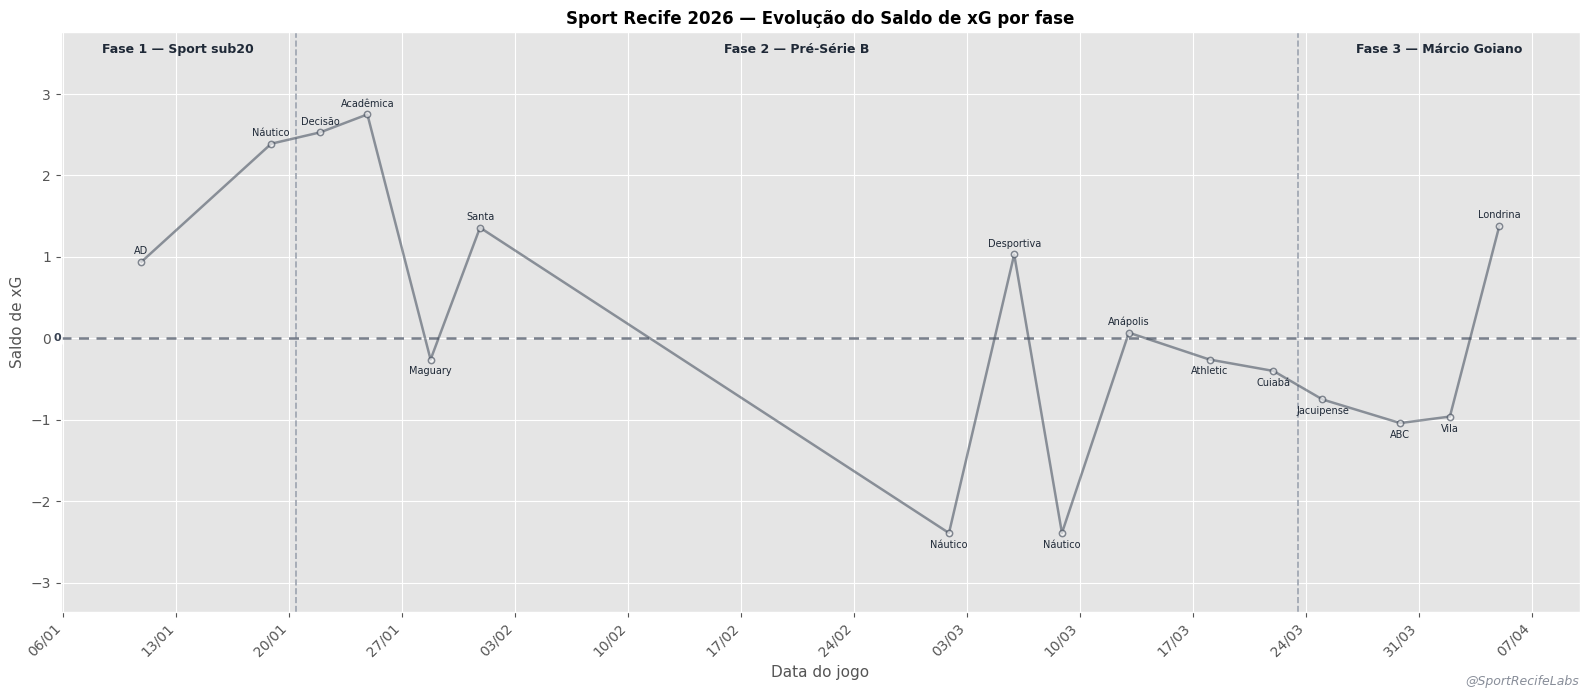

Gráfico salvo em ..\data\processed\2026\sport\sport_2026_xg_evolucao_fases_marcadores.png


In [3]:
fig, ax = plt.subplots(figsize=(16, 7))

matches['xg_balance'] = matches['xg_for'] - matches['xg_against']

# ── 1. Limites do eixo X ──────────────────────────────────────────────────────
x_min = matches['match_date_utc'].min() - pd.Timedelta(days=5)
x_max = matches['match_date_utc'].max() + pd.Timedelta(days=5)

# ── 2. Fronteiras exatas entre fases ─────────────────────────────────────────
all_phases  = sorted(matches['fase'].unique())
phase_last  = {f: matches.loc[matches['fase'].eq(f), 'match_date_utc'].max() for f in all_phases}
phase_first = {f: matches.loc[matches['fase'].eq(f), 'match_date_utc'].min() for f in all_phases}

boundaries = []
for i in range(len(all_phases) - 1):
    end   = phase_last[all_phases[i]]
    start = phase_first[all_phases[i + 1]]
    boundaries.append(end + (start - end) / 2)

span_limits = [x_min] + boundaries + [x_max]

# ── 3. Linhas verticais nas fronteiras e linha de equilíbrio ─────────────────
for b in boundaries:
    ax.axvline(b, color='#9CA3AF', linewidth=1.2, linestyle='--', zorder=1)
ax.axhline(0, color='#6B7280', linewidth=1.8, linestyle=(0, (4, 3)), alpha=0.9, zorder=1)
ax.text(x_min, 0, '0', fontsize=8, fontweight='bold', color='#374151',
        ha='right', va='center',
        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.9),
        zorder=5)

# ── 4. Linha conectando o saldo de xG real por jogo ─────────────────────────
balance_line = matches[['match_date_utc', 'xg_balance']].dropna(subset=['xg_balance']).copy()
ax.plot(balance_line['match_date_utc'].values, balance_line['xg_balance'].values,
        color='#4B5563', linewidth=1.8, alpha=0.6,
        marker='o', markersize=4.5, markerfacecolor='white', markeredgewidth=1.1,
        markeredgecolor='#374151', zorder=2)

# ── 5. Rótulo por jogo: só o adversário ──────────────────────────────────────
for _, row in matches.dropna(subset=['xg_balance']).iterrows():
    y = row['xg_balance']
    opp = str(row['opponent']).split()[0]
    offset = 4 if y >= 0 else -5
    va = 'bottom' if y >= 0 else 'top'
    ax.annotate(opp,
                xy=(row['match_date_utc'], y),
                xytext=(0, offset), textcoords='offset points',
                fontsize=7, color='#1F2937', ha='center', va=va, zorder=4)

# ── 6. ylim e rótulos de fase ─────────────────────────────────────────────────
all_yvals = matches['xg_balance'].dropna()
max_abs_y = all_yvals.abs().max()
margin = max(max_abs_y * 0.22, 0.25)
y_limit = max_abs_y + margin
ax.set_ylim(-y_limit, y_limit * 1.12)

for i, fase_id in enumerate(all_phases):
    mid_x = span_limits[i] + (span_limits[i + 1] - span_limits[i]) / 2
    ax.text(mid_x, y_limit * 1.08, FASE_LABELS[fase_id],
            ha='center', va='top', fontsize=9, fontweight='bold',
            color='#1F2937', zorder=5)

# ── 7. Formatação ─────────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Data do jogo', fontsize=11)
ax.set_ylabel('Saldo de xG', fontsize=11)
ax.set_title('Sport Recife 2026 — Evolução do Saldo de xG por fase',
             fontsize=12, fontweight='bold')

# ── 8. Assinatura ─────────────────────────────────────────────────────────────
fig.text(0.99, 0.01, '@SportRecifeLabs', ha='right', va='bottom',
         fontsize=9, color='#6B7280', alpha=0.8, style='italic')

plt.tight_layout()
OUTPUT_PNG.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico salvo em {OUTPUT_PNG}')